In [3]:
# Import Pandas library for data manipulation and analysis.
# It is mainly used for loading, cleaning, and processing datasets.
import pandas as pd

# Import NumPy library for numerical computations.
# It provides support for arrays, matrices, and mathematical operations
# required for implementing linear regression calculations.
import numpy as np

# Import Matplotlib library for creating data visualizations such as
# scatter plots, regression lines, and performance analysis graphs.
import matplotlib.pyplot as plt

# Import Seaborn library for advanced statistical data visualization.
# It provides improved plotting styles and additional visualization features.
import seaborn as sns

# Configure Seaborn's default visualization style.
# The white grid background improves readability of statistical plots
# and makes patterns in the data easier to interpret.
sns.set_style("whitegrid")

In [4]:
# -----------------------------------------------------------------------------
# Load the dataset
# -----------------------------------------------------------------------------

# Read the CSV file into a Pandas DataFrame.
df = pd.read_csv("advertising.csv")

# Display the first five rows to verify that the dataset has been loaded correctly.
print(df.head(5))

# Display dataset information such as column names, data types, and missing values.
print(df.info())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None


In [ ]:
# -----------------------------------------------------------------------------
# Prepare the Feature (X => TV, Radio, Newspaper)
# -----------------------------------------------------------------------------

# Extract the feature columns "TV", "Radio", and "Newspaper" from the Pandas DataFrame and convert them to a NumPy array.
X = df[["TV", "Radio", "Newspaper"]].values

print(X.shape)
# print(X)

(200, 3)


In [7]:
# -----------------------------------------------------------------------------
# Prepare the Target Variable (Y => 'Sales')
# -----------------------------------------------------------------------------

# Extract the 'Sales' column as the target variable (Y).
# Convert the 1D target array into a 2D column vector.
Y = df["Sales"].values.reshape(-1, 1)

# Display the shape and contents of the reshaped target vector.
print(Y.shape)
# print(Y)

(200, 1)


In [8]:
# -----------------------------------------------------------------------------
# Shuffle First and then Split the Dataset
# -----------------------------------------------------------------------------

# Set a random seed to ensure the same shuffled indices are generated every run.
np.random.seed(42)

# Generate a random permutation of indices from 0 to the number of samples.
indices = np.random.permutation(len(X))

# Display the shuffled indices.
print(f"indices:\n{indices}")

# Select 80% of the shuffled data (160 samples) for training.
train_indices = indices[40:]
print(len(train_indices))       # Output: 160

# Select the remaining 20% of the data (40 samples) for testing.
test_indices = indices[:40]
print(len(test_indices))        # Output: 40

indices:
[ 95  15  30 158 128 115  69 170 174  45  66 182 165  78 186 177  56 152
  82  68 124  16 148  93  65  60  84  67 125 132   9  18  55  75 150 104
 135 137 164  76  79 197  38  24 122 195  29  19 143  86 114 173   5 126
 117  73 140  98 172  96 169  97  31  12  35 119  42 189  90 136  51 127
 162  41 118 113  26 139 100 111   2  77  46 187 191  85 161  36 190  61
  22 141 101  33  11 194 159   6  27 120   4  32 142 145 109 144  10  62
 112 146 166   0 198 153  70 123  64  44 163  28  40 108 155 156  25  23
 184 147  81  39 168  47  94 154  43 138   3 105  53 133 180 178 185  49
  80  34   7 110  91  83 176 181  89   8  13  59 171 131  17  72 175 134
 167 183  63  54 107  50 196  58  48  88  21  57 160 192 129  37 157 193
   1  52 149 130 151 103  99 116  87  74 121 199  20 188  71 106  14  92
 179 102]
160
40


In [9]:
# -----------------------------------------------------------------------------
# Create Training and Testing Sets
# -----------------------------------------------------------------------------

# Split the feature values using the training and testing indices.
X_train = X[train_indices]
X_test = X[test_indices]

# Display the training and testing feature sets.
print(f"X_train shape:\n{X_train.shape}")
print(f"X_test shape:\n{X_test.shape}")

# Split the target values using the same indices.
Y_train = Y[train_indices]
Y_test = Y[test_indices]

# Display the training and testing target values.
print(f"Y_train shape:\n{Y_train.shape}")
print(f"Y_test shape:\n{Y_test.shape}")

X_train shape:
(160, 3)
X_test shape:
(40, 3)
Y_train shape:
(160, 1)
Y_test shape:
(40, 1)


In [ ]:
# -----------------------------------------------------------------------------
# Train the Multiple Linear Regression Model Using the Normal Equation
# -----------------------------------------------------------------------------

# Normal Equation:
# W = (X^T * X)^-1 * X^T * Y

# Create a column of ones for the bias (intercept) term.
ones_array = np.ones((len(X_train), 1))

# Display the bias column and its dimensions.
# print(ones_array)
print(ones_array.shape)     # Output: (160, 1)

# Add the bias column to the training feature matrix.
# np.c_ is used to concatenate arrays column-wise. Here, we are adding the bias column to the left of the feature matrix.
X = np.c_[ones_array, X_train]

# Display the updated feature matrix.
# print(X)
print(X.shape)     # Output: (160, 4)

# Compute the inverse of (XᵀX).
term_1 = np.linalg.inv(X.T @ X)

# Compute XᵀY.
term_2 = X.T @ Y_train

# Calculate the model weights using the Normal Equation.
model_weights = term_1 @ term_2

# Display the calculated model weights.
print(f"Model Weights:\n{model_weights}")
print(f"Model Weights Shape:\n{model_weights.shape}")    # Output: (4, 1)

# Extract individual weights for interpretation. (w_0, w_1, w_2 and w_3)
w_0 = model_weights[0][0]
print(f"w_0: {w_0}")                                     # Output: 4.71412640221412

w_1 = model_weights[1][0]
print(f"w_1: {w_1}")                                     # Output: 0.05450927083721974

w_2 = model_weights[2][0]
print(f"w_2: {w_2}")                                     # Output: 0.10094536239295704

w_3 = model_weights[3][0]
print(f"w_3: {w_3}")                                     # Output: 0.0043366468220338295


(160, 1)
(160, 4)
Model Weights:
[[4.71412640e+00]
 [5.45092708e-02]
 [1.00945362e-01]
 [4.33664682e-03]]
Model Weights Shape:
(4, 1)
w_0: 4.71412640221412
w_1: 0.05450927083721974
w_2: 0.10094536239295704
w_3: 0.0043366468220338295


In [11]:
# -----------------------------------------------------------------------------
# Predict Training Data
# -----------------------------------------------------------------------------

# Generate predictions for the training dataset.
Y_train_pred = X @ model_weights

# Display the predicted training values.
# print(f"Y_train_pred:\n{Y_train_pred}")
print(f"Y_train_pred shape:\n{Y_train_pred.shape}")    # Output: (160, 1)

Y_train_pred shape:
(160, 1)


In [12]:
# -----------------------------------------------------------------------------
# Predict Testing Data
# -----------------------------------------------------------------------------

# Create a bias column for the testing dataset.
ones_array_test = np.ones((len(X_test), 1))

# Add the bias column to the testing feature matrix.
X_test = np.c_[ones_array_test, X_test]

# Generate predictions for the testing dataset.
Y_test_pred = X_test @ model_weights

# Display the predicted testing values.
# print(f"Y_test_pred:\n{Y_test_pred}")
print(f"Y_test_pred shape:\n{Y_test_pred.shape}")    # Output: (40, 1)

Y_test_pred shape:
(40, 1)


In [13]:
# -----------------------------------------------------------------------------
# Model Evaluation
# -----------------------------------------------------------------------------

# Define a function to calculate the Root Mean Squared Error (RMSE).
def rmse(y_actual, y_pred):
    # RMSE measures the average prediction error.
    return np.sqrt(np.mean((y_actual - y_pred) ** 2))

# Calculate RMSE for the training dataset.
rmse_train = rmse(Y_train, Y_train_pred)
print(f"RMSE for Training Data: {rmse_train}")      # Output: 1.635892005537856

# Calculate RMSE for the testing dataset.
rmse_test = rmse(Y_test, Y_test_pred)
print(f"RMSE for Testing Data: {rmse_test}")        # Output: 1.7052146229349203

RMSE for Training Data: 1.635892005537856
RMSE for Testing Data: 1.7052146229349203


Residuals shape:
(40, 1)


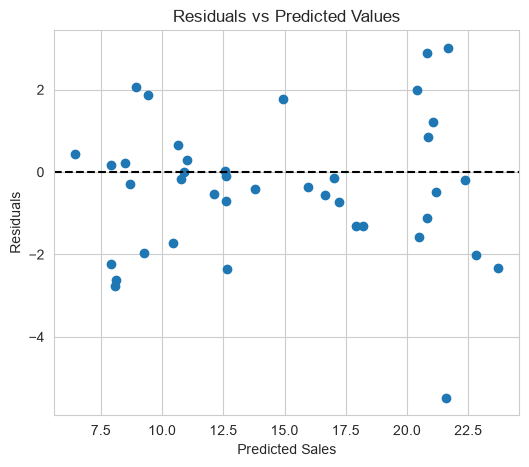

In [15]:
# -----------------------------------------------------------------------------
# Residual Analysis
# -----------------------------------------------------------------------------

# Calculate the residuals (Actual - Predicted values).
residuals = Y_test - Y_test_pred

# Display the residual values.
# print(residuals)
print(f"Residuals shape:\n{residuals.shape}")    # Output: (40, 1)

# Create a scatter plot of predicted values versus residuals.
plt.figure(figsize=(6, 5))
plt.scatter(Y_test_pred, residuals)

# Draw a horizontal reference line at zero error.
plt.axhline(0, linestyle='--', color='black')

# Label the x-axis.
plt.xlabel("Predicted Sales")

# Label the y-axis.
plt.ylabel("Residuals")

# Add a title to the plot.
plt.title("Residuals vs Predicted Values")

# Display the residual plot.
plt.show()